Naive Bayes on the breast cancer dataset. Applies Bayes' theorem with a (naive) assumption that features are independent given the class — fast, probabilistic, surprisingly strong baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = [data.target_names[t] for t in y]
print("Shape:", df.shape)
print(df['target'].value_counts())

Shape: (569, 31)
target
benign       357
malignant    212
Name: count, dtype: int64


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)
y_proba = gnb.predict_proba(X_test_scaled)[:, 1]

print(f"Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test accuracy: 93.57%

Confusion Matrix:
[[ 57   7]
 [  4 103]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.89      0.91        64
      benign       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



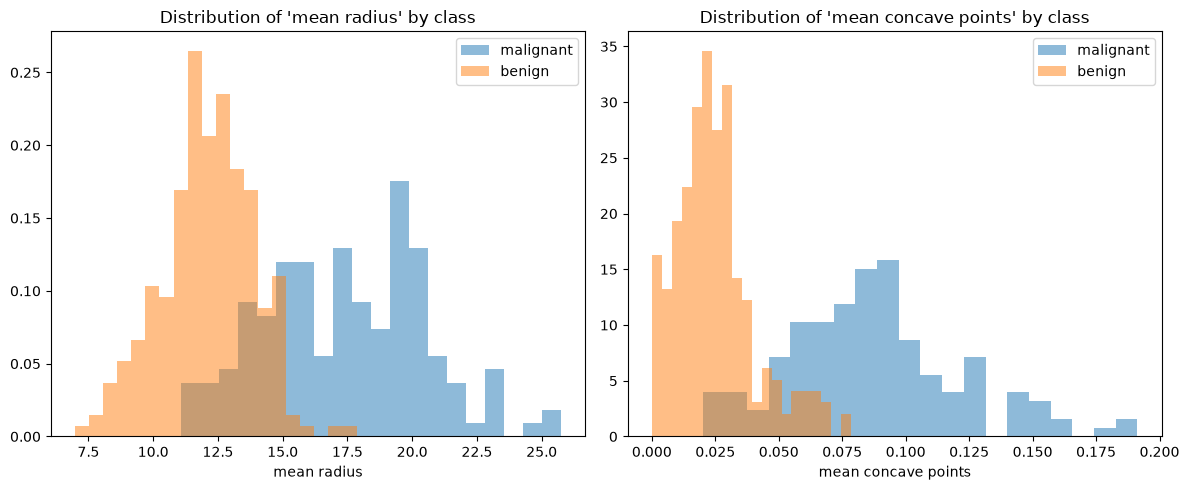

In [4]:
# GaussianNB assumes each feature is normally distributed within each class.
# Visualize that assumption for a couple of features.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat_idx in zip(axes, [0, 7]):
    feat = feature_names[feat_idx]
    for cls in [0, 1]:
        vals = X_train[y_train == cls, feat_idx]
        ax.hist(vals, bins=20, alpha=0.5, label=data.target_names[cls], density=True)
    ax.set_title(f"Distribution of '{feat}' by class")
    ax.set_xlabel(feat)
    ax.legend()
plt.tight_layout()
plt.show()

GaussianNB accuracy:          93.57%
LogisticRegression accuracy:  98.83%


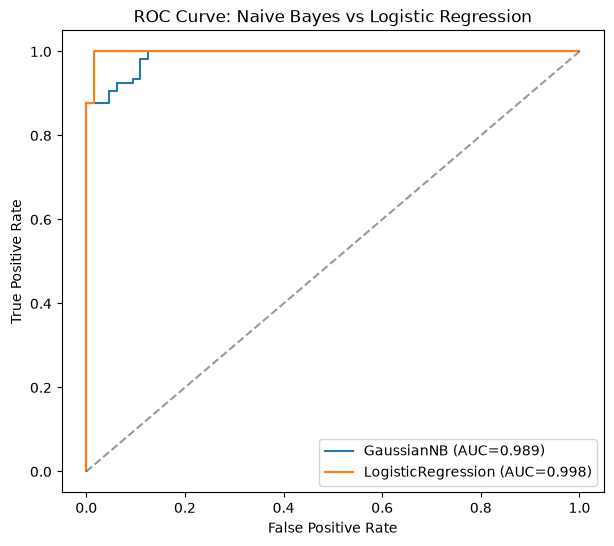

In [5]:
# Naive Bayes is a fast probabilistic baseline -- compare against Logistic Regression
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_scaled, y_train)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print(f"GaussianNB accuracy:          {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"LogisticRegression accuracy:  {accuracy_score(y_test, logreg.predict(X_test_scaled))*100:.2f}%")

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_nb, tpr_nb, label=f'GaussianNB (AUC={roc_auc_score(y_test, y_proba):.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC={roc_auc_score(y_test, logreg_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Naive Bayes vs Logistic Regression')
plt.legend()
plt.show()

In [6]:
# The "naive" independence assumption is usually false -- check correlation between features
corr = pd.DataFrame(X_train, columns=feature_names).corr()
high_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append((feature_names[i], feature_names[j], corr.iloc[i, j]))

print(f"Feature pairs with |correlation| > 0.9: {len(high_corr_pairs)}")
for f1, f2, c in high_corr_pairs[:10]:
    print(f"  {f1} <-> {f2}: {c:.3f}")
print("\nNaive Bayes assumes these are independent -- clearly violated, yet it still performs well.")

Feature pairs with |correlation| > 0.9: 23
  mean radius <-> mean perimeter: 0.998
  mean radius <-> mean area: 0.991
  mean radius <-> worst radius: 0.974
  mean radius <-> worst perimeter: 0.970
  mean radius <-> worst area: 0.945
  mean texture <-> worst texture: 0.917
  mean perimeter <-> mean area: 0.989
  mean perimeter <-> worst radius: 0.974
  mean perimeter <-> worst perimeter: 0.975
  mean perimeter <-> worst area: 0.944

Naive Bayes assumes these are independent -- clearly violated, yet it still performs well.
